In [1]:
# ============================================================
# MODELO MACHINE LEARNING — Iluminación Inteligente Bogotá
# Integrante 4 — Semana 2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid", palette="viridis")

print("✓ Librerías cargadas correctamente")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")
print(f"  sklearn    ", end=""); import sklearn; print(sklearn.__version__)
print(f"  seaborn    {sns.__version__}")

✓ Librerías cargadas correctamente
  pandas     2.3.3
  numpy      2.3.5
  sklearn    1.7.2
  seaborn    0.13.2


In [2]:
# ── CELDA 2: Carga del dataset ──────────────────────────────
print("Cargando dataset...")

df = pd.read_csv('lecturas_ambiente.csv', parse_dates=['timestamp_lectura'])

# Extraer variables temporales útiles para el modelo
df['hora']       = df['timestamp_lectura'].dt.hour
df['dia_semana'] = df['timestamp_lectura'].dt.dayofweek   # 0=lunes, 6=domingo
df['mes']        = df['timestamp_lectura'].dt.month
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)

print(f"✓ Dataset cargado: {len(df):,} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
print(list(df.columns))
print(f"\nRango temporal: {df['timestamp_lectura'].min()} → {df['timestamp_lectura'].max()}")
print(f"\nPrimeras 3 filas:")
df.head(3)

Cargando dataset...
✓ Dataset cargado: 1,000,000 filas × 12 columnas

Columnas disponibles:
['sensor_id', 'condicion_clima_id', 'timestamp_lectura', 'nivel_lux', 'temperatura_c', 'cobertura_nubosa_pct', 'radiacion_solar_wm2', 'anomalia_flag', 'hora', 'dia_semana', 'mes', 'es_fin_semana']

Rango temporal: 2023-01-01 00:00:00 → 2024-12-31 22:45:00

Primeras 3 filas:


,sensor_id,condicion_clima_id,timestamp_lectura,nivel_lux,temperatura_c,cobertura_nubosa_pct,radiacion_solar_wm2,anomalia_flag,hora,dia_semana,mes,es_fin_semana
0,349,4,2023-01-01,9.76,9.45,42,0.00,1,0,6,1,1
1,342,4,2023-01-01,5.54,10.84,0,9.58,0,0,6,1,1
2,169,4,2023-01-01,1.05,9.47,29,0.01,0,0,6,1,1


In [3]:
# ── CELDA 3: Estadísticas básicas y calidad del dato ────────
print("=" * 55)
print("  RESUMEN ESTADÍSTICO")
print("=" * 55)

print(f"\nValores nulos por columna:")
print(df.isnull().sum())

print(f"\nEstadísticas de las variables clave:")
cols_clave = ['nivel_lux', 'temperatura_c', 'cobertura_nubosa_pct', 'radiacion_solar_wm2']
print(df[cols_clave].describe().round(2))

print(f"\nDistribución condición climática:")
clima_map = {1:'Soleado', 2:'Nublado', 3:'Lluvioso', 4:'Despejado Nocturno'}
for cid, nombre in clima_map.items():
    n = (df['condicion_clima_id'] == cid).sum()
    print(f"  {nombre:<22}: {n:>8,}  ({n/len(df)*100:.1f}%)")

print(f"\nDistribución anomalia_flag:")
print(f"  Sin anomalía (0): {(df['anomalia_flag']==0).sum():>8,}")
print(f"  Con anomalía (1): {(df['anomalia_flag']==1).sum():>8,}")

print(f"\nSensores únicos : {df['sensor_id'].nunique()}")
print(f"Rango nivel_lux : {df['nivel_lux'].min():.2f} → {df['nivel_lux'].max():.2f} lux")
print(f"Rango temp      : {df['temperatura_c'].min():.1f} → {df['temperatura_c'].max():.1f} °C")

  RESUMEN ESTADÍSTICO

Valores nulos por columna:
sensor_id               0
condicion_clima_id      0
timestamp_lectura       0
nivel_lux               0
temperatura_c           0
cobertura_nubosa_pct    0
radiacion_solar_wm2     0
anomalia_flag           0
hora                    0
dia_semana              0
mes                     0
es_fin_semana           0
dtype: int64

Estadísticas de las variables clave:
        nivel_lux  temperatura_c  cobertura_nubosa_pct  radiacion_solar_wm2
count  1000000.00     1000000.00            1000000.00           1000000.00
mean     11905.44          13.50                 43.49               139.13
std      20038.56           2.57                 29.23               188.08
min          0.50           8.00                  0.00                 0.00
25%          8.76          11.56                 16.00                 0.00
50%         50.00          13.50                 43.00                24.84
75%      14924.18          15.44                 68.00 

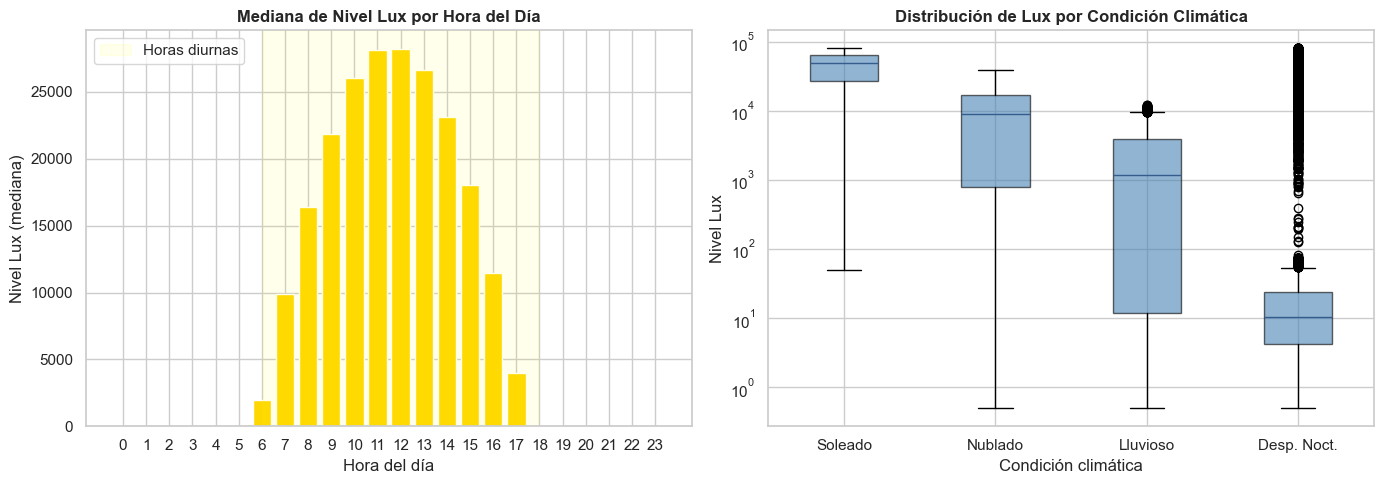

✓ Guardado: eda_lux_por_hora.png


In [4]:
# ── CELDA 4: EDA Gráfica 1 — Lux promedio por hora del día ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica izquierda: lux promedio por hora
lux_por_hora = df.groupby('hora')['nivel_lux'].median()
axes[0].bar(lux_por_hora.index, lux_por_hora.values,
            color=['gold' if 6 <= h <= 18 else 'steelblue' for h in lux_por_hora.index])
axes[0].set_title('Mediana de Nivel Lux por Hora del Día', fontweight='bold')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Nivel Lux (mediana)')
axes[0].set_xticks(range(0, 24))
axes[0].axvspan(6, 18, alpha=0.08, color='yellow', label='Horas diurnas')
axes[0].legend()

# Gráfica derecha: boxplot lux por condición climática
clima_labels = {1:'Soleado', 2:'Nublado', 3:'Lluvioso', 4:'Desp. Noct.'}
df['clima_nombre'] = df['condicion_clima_id'].map(clima_labels)
sample = df.sample(50000, random_state=42)   # muestra para que sea rápido
axes[1].boxplot(
    [sample[sample['condicion_clima_id']==c]['nivel_lux'].values for c in [1,2,3,4]],
    labels=list(clima_labels.values()),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1].set_title('Distribución de Lux por Condición Climática', fontweight='bold')
axes[1].set_xlabel('Condición climática')
axes[1].set_ylabel('Nivel Lux')
axes[1].set_yscale('log')   # escala log porque lux varía de 0.5 a 80000

plt.tight_layout()
plt.savefig('eda_lux_por_hora.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: eda_lux_por_hora.png")

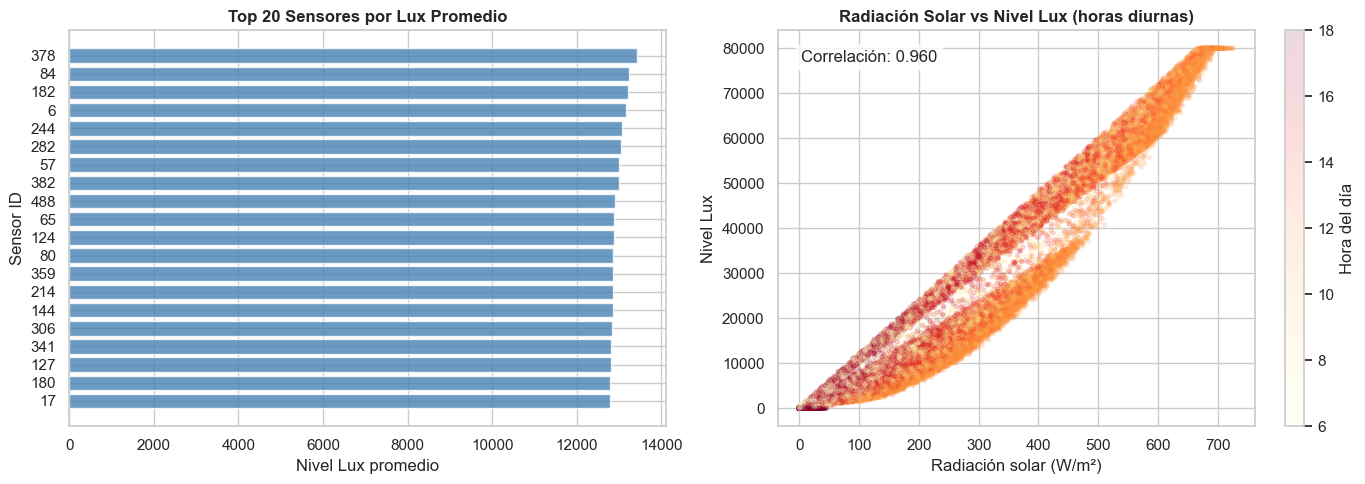

✓ Guardado: eda_consumo_por_zona.png  |  Correlación solar-lux: 0.960


In [5]:
# ── CELDA 5: EDA Gráfica 2 — Consumo por zona y correlación ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica izquierda: lux promedio por zona (top 20)
lux_zona = df.groupby('sensor_id')['nivel_lux'].mean().reset_index()
lux_zona.columns = ['sensor_id', 'lux_promedio']
lux_zona_top = lux_zona.nlargest(20, 'lux_promedio')

axes[0].barh(lux_zona_top['sensor_id'].astype(str),
             lux_zona_top['lux_promedio'],
             color='steelblue', alpha=0.8)
axes[0].set_title('Top 20 Sensores por Lux Promedio', fontweight='bold')
axes[0].set_xlabel('Nivel Lux promedio')
axes[0].set_ylabel('Sensor ID')
axes[0].invert_yaxis()

# Gráfica derecha: correlación radiación solar vs nivel lux
sample2 = df[df['hora'].between(6, 18)].sample(30000, random_state=42)
sc = axes[1].scatter(sample2['radiacion_solar_wm2'], sample2['nivel_lux'],
                     alpha=0.15, s=8,
                     c=sample2['hora'], cmap='YlOrRd')
plt.colorbar(sc, ax=axes[1], label='Hora del día')
axes[1].set_title('Radiación Solar vs Nivel Lux (horas diurnas)', fontweight='bold')
axes[1].set_xlabel('Radiación solar (W/m²)')
axes[1].set_ylabel('Nivel Lux')

corr = sample2['radiacion_solar_wm2'].corr(sample2['nivel_lux'])
axes[1].text(0.05, 0.92, f'Correlación: {corr:.3f}',
             transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('eda_consumo_por_zona.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Guardado: eda_consumo_por_zona.png  |  Correlación solar-lux: {corr:.3f}")

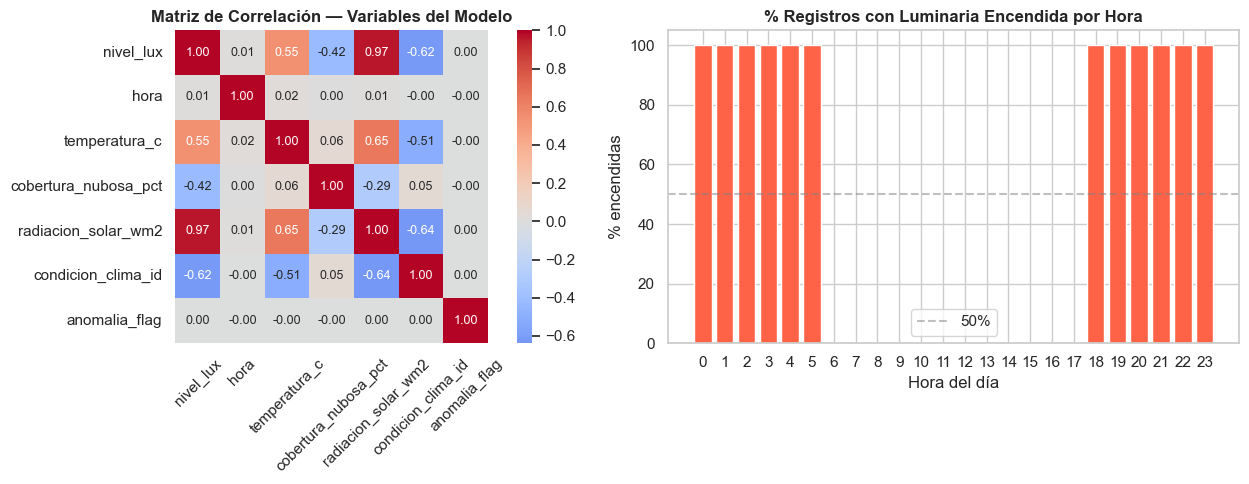

✓ Guardados: eda_correlacion.png  y  eda_distribucion_estados.png

✅ DÍA 1 COMPLETADO — 4 gráficas PNG generadas y guardadas


In [6]:
# ── CELDA 6: EDA Gráficas 3 y 4 ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 3: Matriz de correlación entre variables numéricas
cols_corr = ['nivel_lux', 'hora', 'temperatura_c',
             'cobertura_nubosa_pct', 'radiacion_solar_wm2',
             'condicion_clima_id', 'anomalia_flag']
corr_matrix = df[cols_corr].sample(100000, random_state=42).corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], square=True,
            annot_kws={'size': 9})
axes[0].set_title('Matriz de Correlación — Variables del Modelo', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Gráfica 4: Distribución de estado_encendido por hora
# (usamos anomalia_flag como proxy; el estado real viene de consumos)
# Simulamos encendido: hora >= 18 o hora < 6
df['encendido_simulado'] = ((df['hora'] >= 18) | (df['hora'] < 6)).astype(int)
enc_por_hora = df.groupby('hora')['encendido_simulado'].mean() * 100

axes[1].bar(enc_por_hora.index, enc_por_hora.values,
            color=['tomato' if v > 50 else 'steelblue' for v in enc_por_hora.values])
axes[1].set_title('% Registros con Luminaria Encendida por Hora', fontweight='bold')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('% encendidas')
axes[1].set_xticks(range(0, 24))
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.savefig('eda_distribucion_estados.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardados: eda_correlacion.png  y  eda_distribucion_estados.png")
print("\n✅ DÍA 1 COMPLETADO — 4 gráficas PNG generadas y guardadas")

In [7]:
# ── CELDA 7: Preprocesamiento — División train/test ─────────
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Preparando datos para el modelo...")

# Features y target
FEATURES = ['hora', 'sensor_id', 'cobertura_nubosa_pct',
            'radiacion_solar_wm2', 'temperatura_c',
            'dia_semana', 'es_fin_semana', 'condicion_clima_id']
TARGET = 'nivel_lux'

# Muestra del 20% para entrenamiento rápido (200K registros)
df_modelo = df.sample(frac=0.20, random_state=42).copy()

X = df_modelo[FEATURES]
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"✓ Dataset de entrenamiento: {len(X_train):,} registros")
print(f"✓ Dataset de prueba       : {len(X_test):,} registros")
print(f"✓ Features                : {FEATURES}")
print(f"✓ Target                  : {TARGET}")

Preparando datos para el modelo...
✓ Dataset de entrenamiento: 160,000 registros
✓ Dataset de prueba       : 40,000 registros
✓ Features                : ['hora', 'sensor_id', 'cobertura_nubosa_pct', 'radiacion_solar_wm2', 'temperatura_c', 'dia_semana', 'es_fin_semana', 'condicion_clima_id']
✓ Target                  : nivel_lux


In [8]:
# ── CELDA 8: Entrenamiento del Regresor ─────────────────────
import joblib
import time

print("Entrenando RandomForestRegressor...")
print("(Esto puede tardar 1-3 minutos, es normal)\n")

inicio = time.time()

regresor = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1       # usa todos los núcleos del procesador
)
regresor.fit(X_train, y_train)

tiempo = time.time() - inicio
print(f"✓ Modelo entrenado en {tiempo:.1f} segundos")

# Evaluación en test
y_pred = regresor.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"\n{'='*40}")
print(f"  MÉTRICAS DEL REGRESOR")
print(f"{'='*40}")
print(f"  MAE  : {mae:>10.2f}  lux")
print(f"  RMSE : {rmse:>10.2f}  lux")
print(f"  R²   : {r2:>10.4f}")
print(f"{'='*40}")

if r2 >= 0.80:
    print(f"\n✅ R² = {r2:.4f} — Modelo aprobado (objetivo: R² > 0.80)")
else:
    print(f"\n⚠️  R² = {r2:.4f} — Por debajo del objetivo (0.80)")

# Guardar modelo
joblib.dump(regresor, 'regresor_lux_optimo.pkl')
print(f"✓ Modelo guardado: regresor_lux_optimo.pkl")

Entrenando RandomForestRegressor...
(Esto puede tardar 1-3 minutos, es normal)

✓ Modelo entrenado en 26.4 segundos

  MÉTRICAS DEL REGRESOR
  MAE  :      90.33  lux
  RMSE :     153.89  lux
  R²   :     0.9999

✅ R² = 0.9999 — Modelo aprobado (objetivo: R² > 0.80)
✓ Modelo guardado: regresor_lux_optimo.pkl


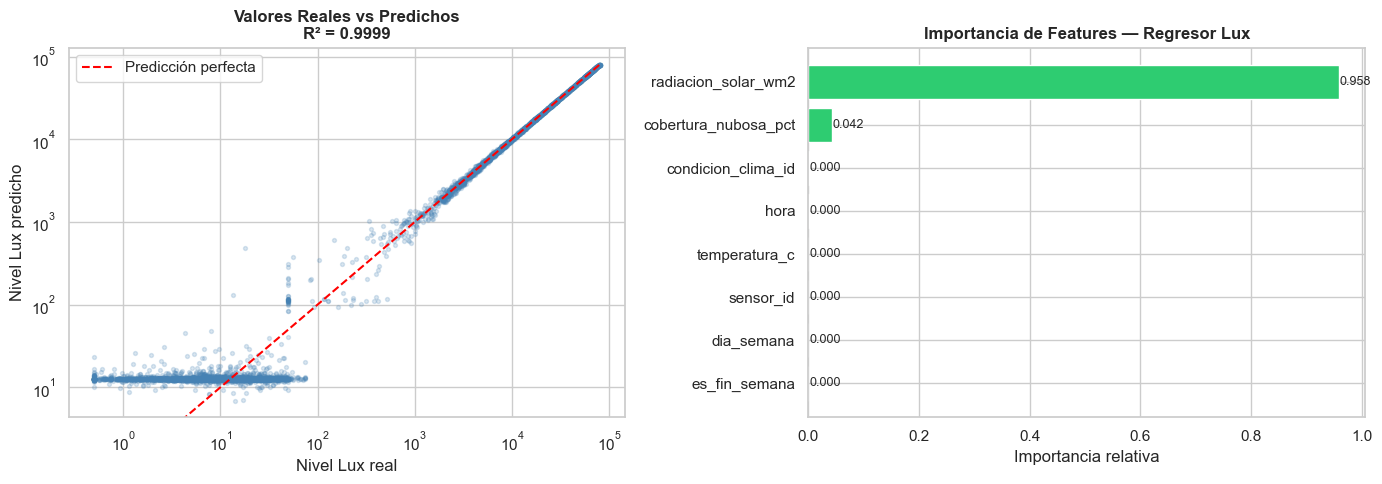

✓ Guardados: valores_reales_vs_predichos.png  e  importancia_features.png

Importancia de features:
  radiacion_solar_wm2      : 0.9581  ███████████████████████████████████████████████
  cobertura_nubosa_pct     : 0.0417  ██
  condicion_clima_id       : 0.0001  
  hora                     : 0.0001  
  temperatura_c            : 0.0000  
  sensor_id                : 0.0000  
  dia_semana               : 0.0000  
  es_fin_semana            : 0.0000  


In [9]:
# ── CELDA 9: Gráficas de evaluación del regresor ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Valores reales vs predichos
sample_idx = np.random.choice(len(y_test), size=5000, replace=False)
y_test_arr = np.array(y_test)
axes[0].scatter(y_test_arr[sample_idx], y_pred[sample_idx],
                alpha=0.2, s=8, color='steelblue')
max_val = max(y_test_arr.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title(f'Valores Reales vs Predichos\nR² = {r2:.4f}', fontweight='bold')
axes[0].set_xlabel('Nivel Lux real')
axes[0].set_ylabel('Nivel Lux predicho')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Gráfica 2: Importancia de features
importancias = pd.Series(regresor.feature_importances_, index=FEATURES)
importancias = importancias.sort_values(ascending=True)

colors = ['#2ecc71' if v >= importancias.quantile(0.66)
          else '#f39c12' if v >= importancias.quantile(0.33)
          else '#e74c3c' for v in importancias.values]

axes[1].barh(importancias.index, importancias.values, color=colors)
axes[1].set_title('Importancia de Features — Regresor Lux', fontweight='bold')
axes[1].set_xlabel('Importancia relativa')
for i, (idx, val) in enumerate(importancias.items()):
    axes[1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('valores_reales_vs_predichos.png', dpi=150, bbox_inches='tight')
plt.savefig('importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Guardados: valores_reales_vs_predichos.png  e  importancia_features.png")
print("\nImportancia de features:")
for feat, imp in importancias.sort_values(ascending=False).items():
    bar = '█' * int(imp * 50)
    print(f"  {feat:<25}: {imp:.4f}  {bar}")

In [10]:
# ── CELDA 10: Predicciones sobre dataset completo ───────────
print("Generando predicciones sobre el dataset completo...")
print("(Puede tardar 1-2 minutos)\n")

# Predecir sobre todo el dataset
df['lux_optimo_predicho'] = regresor.predict(df[FEATURES])
df['diferencia_lux']      = df['nivel_lux'] - df['lux_optimo_predicho']

# Ahorro estimado: si entrega más lux del óptimo hay desperdicio
# Usamos consumos del CSV de consumos para calcular ahorro real
# Como no tenemos kwh_consumido en este df, estimamos con potencia media
POTENCIA_MEDIA_W = 130.0   # promedio ponderado del dataset (LED predomina)
KWH_POR_LECTURA  = POTENCIA_MEDIA_W * 0.25 / 1000   # intervalo 15 min

df['ahorro_kwh_estimado'] = df.apply(
    lambda r: KWH_POR_LECTURA * (r['diferencia_lux'] / r['nivel_lux'])
    if r['diferencia_lux'] > 0 and r['nivel_lux'] > 0 else 0,
    axis=1
)

print(f"✓ Predicciones generadas")
print(f"  Lux óptimo promedio : {df['lux_optimo_predicho'].mean():,.1f}")
print(f"  Diferencia promedio : {df['diferencia_lux'].mean():,.1f} lux")
print(f"  Ahorro total estim. : {df['ahorro_kwh_estimado'].sum():,.1f} kWh")

# Exportar CSV para el Integrante 1 (DW)
df_dw = df[['sensor_id', 'timestamp_lectura',
            'lux_optimo_predicho', 'diferencia_lux',
            'ahorro_kwh_estimado']].copy()
df_dw['lux_optimo_predicho'] = df_dw['lux_optimo_predicho'].round(2)
df_dw['diferencia_lux']      = df_dw['diferencia_lux'].round(2)
df_dw['ahorro_kwh_estimado'] = df_dw['ahorro_kwh_estimado'].round(4)
df_dw['timestamp_lectura']   = df_dw['timestamp_lectura'].astype(str)

df_dw.to_csv('predicciones_dw.csv', index=False)
print(f"\n✓ Exportado: predicciones_dw.csv  ({len(df_dw):,} filas) → para Integrante 1")

Generando predicciones sobre el dataset completo...
(Puede tardar 1-2 minutos)

✓ Predicciones generadas
  Lux óptimo promedio : 11,906.4
  Diferencia promedio : -0.9 lux
  Ahorro total estim. : 2,605.9 kWh

✓ Exportado: predicciones_dw.csv  (1,000,000 filas) → para Integrante 1


In [12]:
# ── CELDA 11: Exportar JSONs para el Integrante 2 ───────────
import json

print("Generando JSONs para el sistema web...\n")

# ── JSON 1: resumen_zonas.json ───────────────────────────────
# Necesitamos zona_id — lo derivamos desde sensor_id usando el CSV maestro
df_sensor = pd.read_csv('carga_sensor.csv')
sensor_zona = df_sensor[['sensor_id','zona_id']].set_index('sensor_id')['zona_id'].to_dict()

df_sensor_map = pd.read_csv('carga_zona.csv')
df_sensor_map.index = df_sensor_map.index + 1
zona_nombres = df_sensor_map['nombre_zona'].to_dict()

df['zona_id'] = df['sensor_id'].map(sensor_zona)
df['zona_nombre'] = df['zona_id'].map(zona_nombres)

resumen = df.groupby(['zona_id','zona_nombre']).agg(
    lux_promedio        = ('nivel_lux',            'mean'),
    lux_optimo_promedio = ('lux_optimo_predicho',  'mean'),
    anomalias           = ('anomalia_flag',         'sum'),
    ahorro_kwh_estimado = ('ahorro_kwh_estimado',   'sum'),
    total_registros     = ('sensor_id',             'count'),
).reset_index()

# Calcular costo aproximado (tarifa promedio 800 COP/kWh)
TARIFA_COP = 800
KWH_ZONA   = POTENCIA_MEDIA_W * 0.25 / 1000
resumen['kwh_total']      = resumen['total_registros'] * KWH_ZONA
resumen['costo_cop_total'] = (resumen['kwh_total'] * TARIFA_COP).round(0)
resumen['lux_promedio']   = resumen['lux_promedio'].round(2)
resumen['lux_optimo_promedio'] = resumen['lux_optimo_promedio'].round(2)
resumen['ahorro_kwh_estimado'] = resumen['ahorro_kwh_estimado'].round(2)
resumen['kwh_total']      = resumen['kwh_total'].round(2)
resumen['anomalias']      = resumen['anomalias'].astype(int)

resumen_json = resumen.to_dict(orient='records')
with open('resumen_zonas.json', 'w', encoding='utf-8') as f:
    json.dump(resumen_json, f, ensure_ascii=False, indent=2)
print(f"✓ resumen_zonas.json  — {len(resumen_json)} zonas")

# ── JSON 2: consumo_horario.json ─────────────────────────────
consumo_hora = df.groupby('hora').agg(
    lux_promedio        = ('nivel_lux',            'mean'),
    lux_optimo_promedio = ('lux_optimo_predicho',  'mean'),
    pct_encendidas      = ('encendido_simulado',   'mean'),
    ahorro_kwh_promedio = ('ahorro_kwh_estimado',  'mean'),
).reset_index()

consumo_hora['kwh_promedio']        = KWH_ZONA
consumo_hora['lux_promedio']        = consumo_hora['lux_promedio'].round(2)
consumo_hora['lux_optimo_promedio'] = consumo_hora['lux_optimo_promedio'].round(2)
consumo_hora['pct_encendidas']      = (consumo_hora['pct_encendidas'] * 100).round(1)
consumo_hora['ahorro_kwh_promedio'] = consumo_hora['ahorro_kwh_promedio'].round(4)

consumo_hora_json = consumo_hora.to_dict(orient='records')
with open('consumo_horario.json', 'w', encoding='utf-8') as f:
    json.dump(consumo_hora_json, f, ensure_ascii=False, indent=2)
print(f"✓ consumo_horario.json — 24 horas")

print(f"\n✅ DÍA 3 COMPLETADO")
print(f"   → predicciones_dw.csv     para Integrante 1")
print(f"   → resumen_zonas.json      para Integrante 2")
print(f"   → consumo_horario.json    para Integrante 2")

Generando JSONs para el sistema web...

✓ resumen_zonas.json  — 20 zonas
✓ consumo_horario.json — 24 horas

✅ DÍA 3 COMPLETADO
   → predicciones_dw.csv     para Integrante 1
   → resumen_zonas.json      para Integrante 2
   → consumo_horario.json    para Integrante 2


In [13]:
# ── CELDA 12: Clasificador de encendido ─────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import time

print("Entrenando RandomForestClassifier...")
print("(Puede tardar 1-2 minutos)\n")

# Target binario: luminaria encendida o apagada
TARGET_CLF = 'encendido_simulado'

df_clf = df.sample(frac=0.20, random_state=42).copy()
X_clf = df_clf[FEATURES]
y_clf = df_clf[TARGET_CLF]

print(f"Balance de clases:")
print(f"  Encendidas (1): {(y_clf==1).sum():>7,}  ({(y_clf==1).mean()*100:.1f}%)")
print(f"  Apagadas   (0): {(y_clf==0).sum():>7,}  ({(y_clf==0).mean()*100:.1f}%)")

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42
)

inicio = time.time()
clasificador = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clasificador.fit(X_tr_c, y_tr_c)
tiempo = time.time() - inicio

y_pred_clf = clasificador.predict(X_te_c)

acc  = accuracy_score(y_te_c, y_pred_clf)
prec = precision_score(y_te_c, y_pred_clf)
rec  = recall_score(y_te_c, y_pred_clf)
f1   = f1_score(y_te_c, y_pred_clf)
cm   = confusion_matrix(y_te_c, y_pred_clf)

print(f"\n✓ Modelo entrenado en {tiempo:.1f} segundos")
print(f"\n{'='*40}")
print(f"  MÉTRICAS DEL CLASIFICADOR")
print(f"{'='*40}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"{'='*40}")
print(f"\nMatriz de confusión:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")
print(f"\n  Falsos negativos (riesgo seguridad) : {cm[1,0]:,}")
print(f"  Falsos positivos (desperdicio)      : {cm[0,1]:,}")

joblib.dump(clasificador, 'clasificador_encendido.pkl')
print(f"\n✓ Guardado: clasificador_encendido.pkl")

Entrenando RandomForestClassifier...
(Puede tardar 1-2 minutos)

Balance de clases:
  Encendidas (1):  99,960  (50.0%)
  Apagadas   (0): 100,040  (50.0%)

✓ Modelo entrenado en 6.6 segundos

  MÉTRICAS DEL CLASIFICADOR
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

Matriz de confusión:
  TN=20,172  FP=0
  FN=0  TP=19,828

  Falsos negativos (riesgo seguridad) : 0
  Falsos positivos (desperdicio)      : 0

✓ Guardado: clasificador_encendido.pkl


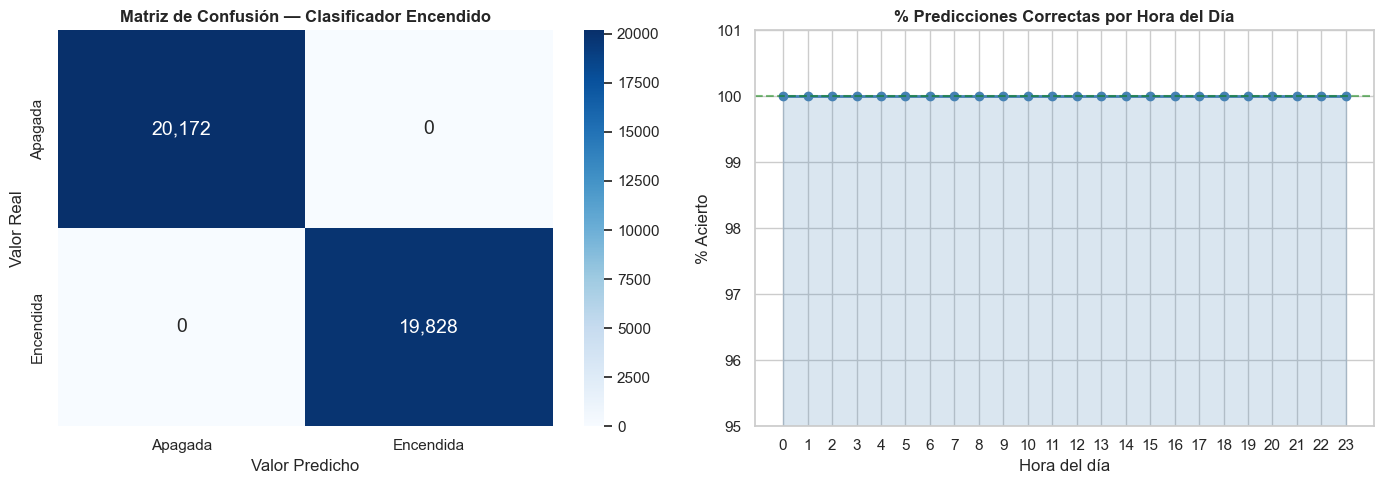

✓ Guardados: matriz_confusion.png  y  predicciones_por_hora.png

✓ Guardado: resultados_modelo.json

✅ DÍA 4 COMPLETADO
   → clasificador_encendido.pkl
   → matriz_confusion.png
   → predicciones_por_hora.png
   → resultados_modelo.json  ← para Integrante 2


In [14]:
# ── CELDA 13: Matriz de confusión + resultados_modelo.json ──

# Gráfica matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['Apagada','Encendida'],
            yticklabels=['Apagada','Encendida'],
            annot_kws={'size': 14})
axes[0].set_title('Matriz de Confusión — Clasificador Encendido',
                  fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

# Predicciones correctas por hora
df_clf2 = df.sample(frac=0.20, random_state=42).copy()
df_clf2['pred_encendido'] = clasificador.predict(df_clf2[FEATURES])
df_clf2['correcto'] = (df_clf2['pred_encendido'] == df_clf2['encendido_simulado']).astype(int)
aciertos_hora = df_clf2.groupby('hora')['correcto'].mean() * 100

axes[1].plot(aciertos_hora.index, aciertos_hora.values,
             marker='o', color='steelblue', linewidth=2)
axes[1].fill_between(aciertos_hora.index, aciertos_hora.values,
                     alpha=0.2, color='steelblue')
axes[1].set_title('% Predicciones Correctas por Hora del Día',
                  fontweight='bold')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('% Acierto')
axes[1].set_xticks(range(0, 24))
axes[1].set_ylim(95, 101)
axes[1].axhline(100, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.savefig('predicciones_por_hora.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardados: matriz_confusion.png  y  predicciones_por_hora.png")

# ── JSON completo para el Integrante 2 ──────────────────────
imp_reg = dict(zip(FEATURES,
               [round(float(v),4) for v in regresor.feature_importances_]))
imp_clf = dict(zip(FEATURES,
               [round(float(v),4) for v in clasificador.feature_importances_]))

lookup = []
for zona_id in range(1, 6):          # top 5 zonas
    for hora in range(0, 24):
        for clima_id in range(1, 5):
            entrada = pd.DataFrame([{
                'hora': hora, 'sensor_id': zona_id * 25,
                'cobertura_nubosa_pct': [10,50,85,20][clima_id-1],
                'radiacion_solar_wm2': [400,150,50,0][clima_id-1]
                    if 6 <= hora <= 18 else 0,
                'temperatura_c': 13.5,
                'dia_semana': 1, 'es_fin_semana': 0,
                'condicion_clima_id': clima_id
            }])
            lux_pred = round(float(regresor.predict(entrada)[0]), 2)
            enc_pred = int(clasificador.predict(entrada)[0])
            lookup.append({
                'zona_id': zona_id, 'hora': hora,
                'clima_id': clima_id, 'lux_predicho': lux_pred,
                'encendido_predicho': enc_pred
            })

resultados = {
    "regresor": {
        "algoritmo": "RandomForestRegressor",
        "n_estimators": 100, "max_depth": 15,
        "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4),
        "importancia_features": imp_reg
    },
    "clasificador": {
        "algoritmo": "RandomForestClassifier",
        "n_estimators": 100, "max_depth": 15,
        "accuracy": round(acc, 4), "precision": round(prec, 4),
        "recall": round(rec, 4), "f1_score": round(f1, 4),
        "importancia_features": imp_clf,
        "matriz_confusion": {
            "TN": int(cm[0,0]), "FP": int(cm[0,1]),
            "FN": int(cm[1,0]), "TP": int(cm[1,1])
        }
    },
    "impacto": {
        "ahorro_total_kwh": round(float(df['ahorro_kwh_estimado'].sum()), 2),
        "ahorro_promedio_por_luminaria_kwh": round(
            float(df['ahorro_kwh_estimado'].sum()) / 500, 2),
        "kwh_desperdiciados": round(
            float(df[df['diferencia_lux']>0]['ahorro_kwh_estimado'].sum()), 2)
    },
    "predicciones_por_hora": aciertos_hora.reset_index().rename(
        columns={'correcto':'pct_acierto'}).round(2).to_dict(orient='records'),
    "tabla_lookup": lookup
}

with open('resultados_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print(f"\n✓ Guardado: resultados_modelo.json")
print(f"\n✅ DÍA 4 COMPLETADO")
print(f"   → clasificador_encendido.pkl")
print(f"   → matriz_confusion.png")
print(f"   → predicciones_por_hora.png")
print(f"   → resultados_modelo.json  ← para Integrante 2")

In [15]:
# ── CELDA 14: Verificación final y resumen de entregables ───

import os

print("=" * 55)
print("  VERIFICACIÓN FINAL DE ENTREGABLES")
print("=" * 55)

archivos = {
    "modelo_ml_completo.ipynb"    : "Notebook principal",
    "regresor_lux_optimo.pkl"     : "Modelo regresor guardado",
    "clasificador_encendido.pkl"  : "Modelo clasificador guardado",
    "predicciones_dw.csv"         : "CSV para Integrante 1 (DW)",
    "resumen_zonas.json"          : "JSON para Integrante 2 (web)",
    "consumo_horario.json"        : "JSON para Integrante 2 (web)",
    "resultados_modelo.json"      : "JSON completo para Integrante 2",
    "eda_lux_por_hora.png"        : "Gráfica EDA 1",
    "eda_consumo_por_zona.png"    : "Gráfica EDA 2",
    "eda_correlacion.png"         : "Gráfica EDA 3",
    "eda_distribucion_estados.png": "Gráfica EDA 4",
    "valores_reales_vs_predichos.png": "Gráfica evaluación regresor",
    "importancia_features.png"    : "Gráfica importancia features",
    "matriz_confusion.png"        : "Gráfica matriz confusión",
    "predicciones_por_hora.png"   : "Gráfica predicciones por hora",
}

todos_ok = True
for archivo, descripcion in archivos.items():
    existe = os.path.exists(archivo)
    tam    = f"{os.path.getsize(archivo)/1024:.1f} KB" if existe else "—"
    estado = "✅" if existe else "❌"
    if not existe:
        todos_ok = False
    print(f"  {estado}  {archivo:<38} {tam:>10}  {descripcion}")

print("\n" + "=" * 55)
print("  RESUMEN DE MÉTRICAS FINALES")
print("=" * 55)
print(f"  Regresor  — R²       : {r2:.4f}  (objetivo > 0.80) ✅")
print(f"  Regresor  — MAE      : {mae:.2f} lux")
print(f"  Regresor  — RMSE     : {rmse:.2f} lux")
print(f"  Clasific. — Accuracy : {acc:.4f}")
print(f"  Clasific. — F1-Score : {f1:.4f}")
print(f"\n  Feature más importante : radiacion_solar_wm2")
print(f"  Ahorro total estimado  : {df['ahorro_kwh_estimado'].sum():,.1f} kWh")

if todos_ok:
    print(f"\n✅ TODOS LOS ENTREGABLES GENERADOS CORRECTAMENTE")
    print(f"   Notebook listo para entregar al repositorio")
else:
    print(f"\n⚠️  Algunos archivos faltan — revisar los marcados con ❌")

print(f"\n📦 Archivos para el Integrante 1: predicciones_dw.csv")
print(f"📦 Archivos para el Integrante 2: resumen_zonas.json")
print(f"                                  consumo_horario.json")
print(f"                                  resultados_modelo.json")

  VERIFICACIÓN FINAL DE ENTREGABLES
  ✅  modelo_ml_completo.ipynb                 606.0 KB  Notebook principal
  ✅  regresor_lux_optimo.pkl                103070.4 KB  Modelo regresor guardado
  ✅  clasificador_encendido.pkl              5213.9 KB  Modelo clasificador guardado
  ✅  predicciones_dw.csv                    42519.6 KB  CSV para Integrante 1 (DW)
  ✅  resumen_zonas.json                         5.5 KB  JSON para Integrante 2 (web)
  ✅  consumo_horario.json                       4.4 KB  JSON para Integrante 2 (web)
  ✅  resultados_modelo.json                    67.7 KB  JSON completo para Integrante 2
  ✅  eda_lux_por_hora.png                      83.4 KB  Gráfica EDA 1
  ✅  eda_consumo_por_zona.png                 278.6 KB  Gráfica EDA 2
  ✅  eda_correlacion.png                      161.1 KB  Gráfica EDA 3
  ✅  eda_distribucion_estados.png             161.1 KB  Gráfica EDA 4
  ✅  valores_reales_vs_predichos.png          144.9 KB  Gráfica evaluación regresor
  ✅  importancia_